# Statistical Inference Illustration
This notebook generates Gaussian-like data, visualizes its histogram, and infers the population mean and variance from the sample. It also includes a separate outlier-contaminated example showing how the inferred mean is skewed.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.labelsize'] = 36
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts, amssymb}')
plt.rc('axes', titlesize=22, labelsize=36)
plt.rc('xtick', labelsize=22, direction='in')
plt.rc('ytick', labelsize=22, direction='in')
plt.rc('figure', figsize=(10, 4), dpi=110)

In [66]:
# Simulate Gaussian-like observations
rng = np.random.default_rng(7)
true_mu = 2.0
true_sigma = 1.3
n = 500
samples = rng.normal(loc=true_mu, scale=true_sigma, size=n)

# Infer mean and variance from the sample
mu_hat = np.mean(samples)
sigma2_hat = np.var(samples, ddof=1)
sigma_hat = np.sqrt(sigma2_hat)

# Standard error and 95% confidence interval for the mean
se_mu = sigma_hat / np.sqrt(n)
ci_low = mu_hat - 1.96 * se_mu
ci_high = mu_hat + 1.96 * se_mu

print(f'Estimated mean (mu_hat): {mu_hat:.4f}')
print(f'Estimated variance (sigma_hat^2): {sigma2_hat:.4f}')
print(f'95% CI for mean: [{ci_low:.4f}, {ci_high:.4f}]')

Estimated mean (mu_hat): 1.8332
Estimated variance (sigma_hat^2): 1.4866
95% CI for mean: [1.7263, 1.9400]


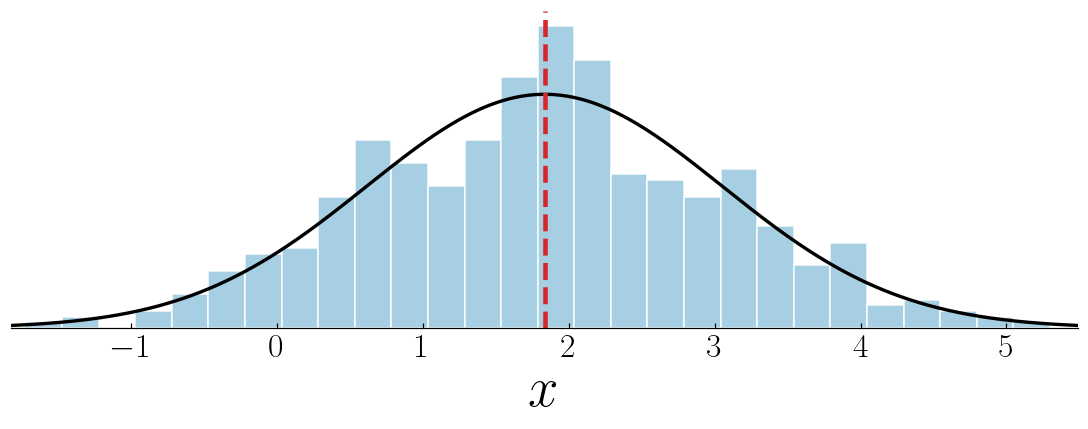

In [67]:
fig, ax = plt.subplots()

# Histogram (empirical distribution)
ax.hist(samples, bins=30, density=True, color='#9ecae1', edgecolor='white', alpha=0.9)

# Fitted Gaussian density using inferred parameters
plot_x_min, plot_x_max = mu_hat - 3 * sigma_hat, mu_hat + 3 * sigma_hat
x_plot = np.linspace(plot_x_min, plot_x_max, 500)
pdf_hat = (1.0 / (np.sqrt(2.0 * np.pi) * sigma_hat)) * np.exp(-0.5 * ((x_plot - mu_hat) / sigma_hat) ** 2)
ax.plot(x_plot, pdf_hat, color='black', linewidth=2.2)

# Visual cue for inferred mean
ax.axvline(mu_hat, color='#d62728', linestyle='--', linewidth=3.0)

# ax.set_title(r'Infer $\mu$ and $\sigma^2$ from Data')
ax.set_xlabel(r'$x$')
ax.set_xlim(plot_x_min, plot_x_max)

# Remove y-axis completely
ax.yaxis.set_visible(False)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('/home/zongchen/mini_mmd/plotting/figures/statistical_inference_illustration.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
# Add ten very large right-tail outliers to the same Gaussian-like observations
outlier = 10.0
outliers = np.full(100, outlier)
outlier_samples = np.concatenate([samples, outliers])
n_outlier = outlier_samples.size

# Infer mean and variance from the contaminated sample
baseline_mu_hat = mu_hat
outlier_mu_hat = np.mean(outlier_samples)
outlier_sigma2_hat = np.var(outlier_samples, ddof=1)
outlier_sigma_hat = np.sqrt(outlier_sigma2_hat)

# Standard error and 95% confidence interval for the mean
outlier_se_mu = outlier_sigma_hat / np.sqrt(n_outlier)
outlier_ci_low = outlier_mu_hat - 1.96 * outlier_se_mu
outlier_ci_high = outlier_mu_hat + 1.96 * outlier_se_mu
mean_shift = outlier_mu_hat - baseline_mu_hat

print(f'Original mean (mu_hat): {baseline_mu_hat:.4f}')
print(f'Outlier value: {outlier:.1f}')
print(f'Number of outliers: {outliers.size}')
print(f'Outlier-contaminated mean (mu_hat): {outlier_mu_hat:.4f}')
print(f'Mean shift due to outliers: {mean_shift:.4f} ({mean_shift / outlier_se_mu:.2f} SEs)')
print(f'Estimated variance (sigma_hat^2): {outlier_sigma2_hat:.4f}')
print(f'95% CI for mean: [{outlier_ci_low:.4f}, {outlier_ci_high:.4f}]')

Original mean (mu_hat): 1.8332
Outlier value: 10.0
Number of outliers: 100
Outlier-contaminated mean (mu_hat): 3.1943
Mean shift due to outliers: 1.3611 (10.28 SEs)
Estimated variance (sigma_hat^2): 10.5174
95% CI for mean: [2.9348, 3.4538]


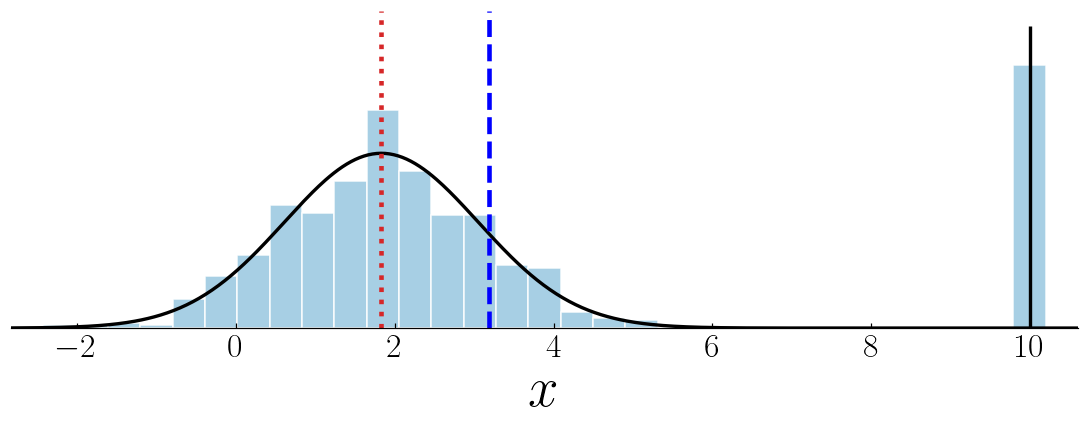

In [69]:
fig, ax = plt.subplots()

# Histogram (empirical distribution), expanded to include the large outlier
outlier_x_min = min(plot_x_min, np.min(outlier_samples) - 0.6)
outlier_x_max = max(plot_x_max, np.max(outlier_samples) + 0.6)
bins = np.linspace(outlier_x_min, outlier_x_max, 34)
ax.hist(outlier_samples, bins=bins, density=True, color='#9ecae1', edgecolor='white', alpha=0.9)

# Mixture density: original Gaussian component plus a Dirac mass at the outlier
x_plot = np.linspace(outlier_x_min, outlier_x_max, 500)
gaussian_weight = samples.size / n_outlier
dirac_weight = outliers.size / n_outlier
gaussian_pdf = gaussian_weight * (1.0 / (np.sqrt(2.0 * np.pi) * sigma_hat)) * np.exp(-0.5 * ((x_plot - mu_hat) / sigma_hat) ** 2)
ax.plot(x_plot, gaussian_pdf, color='black', linewidth=2.2)
dirac_height = 1.15 * max(gaussian_pdf.max(), 1.0 / (bins[1] - bins[0]) * dirac_weight)
ax.vlines(outlier, 0.0, dirac_height, color='black', linewidth=2.2)

# Gray dotted line: original mean; red dashed line: mean after adding the outlier
ax.axvline(baseline_mu_hat, color='#d62728', linestyle=':', linewidth=3.0)
ax.axvline(outlier_mu_hat, color='blue', linestyle='--', linewidth=3.0)
# ax.scatter(outliers, np.full_like(outliers, 0.004), color='#d62728', s=28, zorder=5)
ax.set_xlabel(r'$x$')
ax.set_xlim(outlier_x_min, outlier_x_max)

# Remove y-axis completely
ax.yaxis.set_visible(False)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('/home/zongchen/mini_mmd/plotting/figures/statistical_inference_outlier_illustration.pdf', dpi=300, bbox_inches='tight')
plt.show()
